## **MACHINE LEARNING PROJECT**

Machine Learning (ML) is a branch of artificial intelligence (AI) that enables computers to learn patterns from data and make decisions or predictions without being explicitly programmed.

**Types of Machine Learning**

1.Supervised Learning

- Model learns from labeled data

- Examples: Classification, Regression

2.Unsupervised Learning

- Model finds hidden patterns in unlabeled data

- Examples: Clustering, Dimensionality Reduction

3.Reinforcement Learning

- Model learns through trial and error

- Example: Game-playing agents, robotics

**Common ML Algorithms**

- Linear Regression

- Logistic Regression

- Decision Trees

- Random Forest

- Support Vector Machine (SVM)

- KNN

This project demonstrates a complete end-to-end Machine Learning workflow including data preprocessing, model training, evaluation, and model optimization.

In [1]:
# importing essential modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler,OneHotEncoder,OrdinalEncoder
from imblearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,accuracy_score,ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

## **STUDENT DEPRESSION DATASET**

The Student Depression Dataset contains information about college or school students, including their academic performance, lifestyle habits, emotional well-being, and social factors.
The goal of this dataset is to predict whether a student is experiencing signs of depression based on various personal, educational, and environmental attributes.

In [2]:
# loading student depression dataset
df=pd.read_csv('E:/makbig/Data Science with AI-ML/.venv/project/EDA/Student Depression Dataset.csv')
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


## **EDA**

- Exploratory Data Analysis (EDA) is the process of examining and understanding a dataset before building any model.
- It involves summarizing key characteristics, detecting anomalies, visualizing distributions, and uncovering insights that guide further data preprocessing and modeling.

In [3]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [4]:
df.shape

(27901, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [6]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [7]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [8]:
df.select_dtypes('number').columns

Index(['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Financial Stress', 'Depression'],
      dtype='object')

In [9]:
df.select_dtypes(object).columns

Index(['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits',
       'Degree', 'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='object')

In [10]:
# no of unique values in the Non-numerical features
df.select_dtypes('object').nunique()

Gender                                    2
City                                     52
Profession                               14
Sleep Duration                            5
Dietary Habits                            4
Degree                                   28
Have you ever had suicidal thoughts ?     2
Family History of Mental Illness          2
dtype: int64

In [11]:
for i in df.select_dtypes('object').columns:
    print(i+":",df[i].unique())
    print("-"*100)

Gender: ['Male' 'Female']
----------------------------------------------------------------------------------------------------
City: ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3.0'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']
----------------------------------------------------------------------------------------------------
Profession: ['Student' 'Civil Engineer' 'Architect' 'UX/UI Designer'
 'Digital Marketer' 'Content Writer' 'Educational Consultant' 'Teacher'
 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist']
-----------------------------------------------

In [12]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [13]:
df.dropna(inplace=True)
print('null values',df.isnull().sum())
df.reset_index(drop=True).shape

null values id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


(27898, 18)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop('id',axis=1,inplace=True)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Age'),
  Text(1, 0, 'Academic Pressure'),
  Text(2, 0, 'Work Pressure'),
  Text(3, 0, 'CGPA'),
  Text(4, 0, 'Study Satisfaction'),
  Text(5, 0, 'Job Satisfaction'),
  Text(6, 0, 'Work/Study Hours'),
  Text(7, 0, 'Financial Stress'),
  Text(8, 0, 'Depression')])

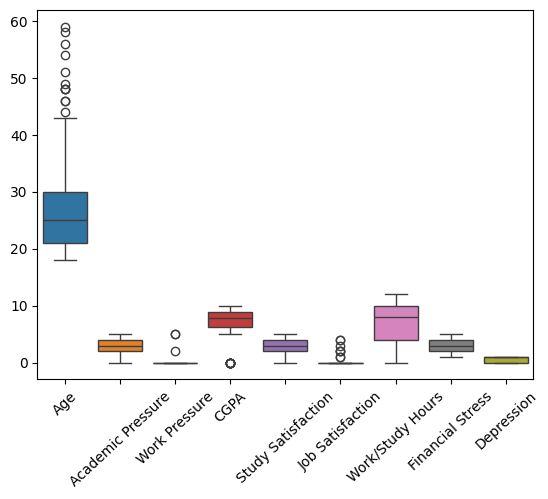

In [16]:
sns.boxplot(df[df.select_dtypes('number').columns])
plt.xticks(rotation=43)

## **FEATURE ENGINEERING**

In [17]:
# rename columns
df.rename(columns={'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts',
                   'Family History of Mental Illness': 'Family Mental History',
                   'Work/Study Hours':'Study Hours'},inplace=True)
df.columns

Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree', 'Suicidal Thoughts',
       'Study Hours', 'Financial Stress', 'Family Mental History',
       'Depression'],
      dtype='object')

In [18]:
# handling wrong entries or mistakes
replace_map = {
    'Less Delhi': 'Delhi',
    'Less than 5 Kalyan': 'Kalyan',
    'Mira': 'Mira-Bhayandar',
    'Nalyan': 'Kalyan',
    'Khaziabad': 'Ghaziabad'
}

df['City'] = df['City'].replace(replace_map)

# Remove obvious person names
invalid = ['Saanvi', 'Vaanya', 'Gaurav', 'Reyansh', 'Kibara', 'Rashi', 'Mihir', 'Nalini', 'Nandini','M.Tech', 'Bhavna', 'City', '3.0', 'Harsha', 'Harsh', 'ME', 'M.Com']
df = df[~df['City'].isin(invalid)].copy()
df.reset_index(drop=True, inplace=True)


<Axes: >

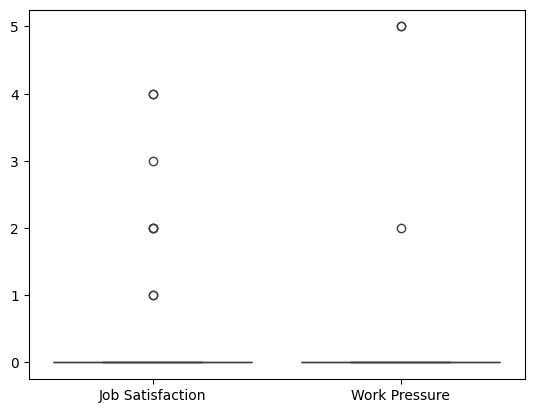

In [19]:
sns.boxplot(df[['Job Satisfaction','Work Pressure']])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Student'),
  Text(1, 0, 'Civil Engineer'),
  Text(2, 0, 'Architect'),
  Text(3, 0, 'UX/UI Designer'),
  Text(4, 0, 'Digital Marketer'),
  Text(5, 0, 'Content Writer'),
  Text(6, 0, 'Educational Consultant'),
  Text(7, 0, 'Teacher'),
  Text(8, 0, 'Manager'),
  Text(9, 0, 'Chef'),
  Text(10, 0, 'Doctor'),
  Text(11, 0, 'Lawyer'),
  Text(12, 0, 'Entrepreneur'),
  Text(13, 0, 'Pharmacist')])

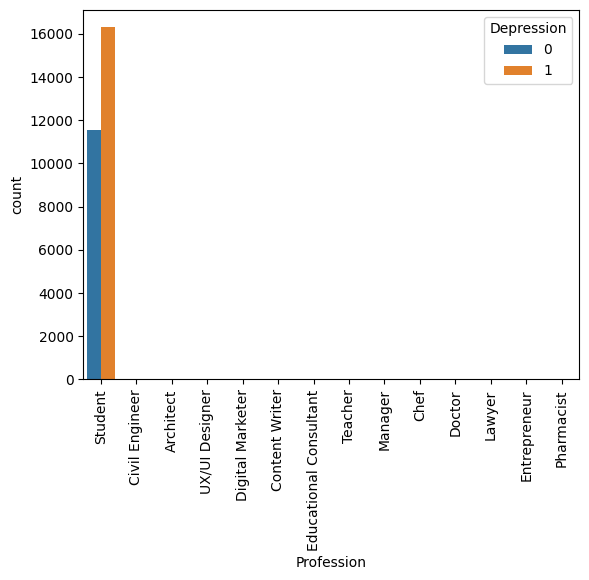

In [20]:
sns.countplot(x=df['Profession'],hue=df['Depression'])
plt.xticks(rotation=90)

In [21]:
# low variance
df.drop(['Work Pressure','Job Satisfaction','Profession'],axis=1,inplace=True)

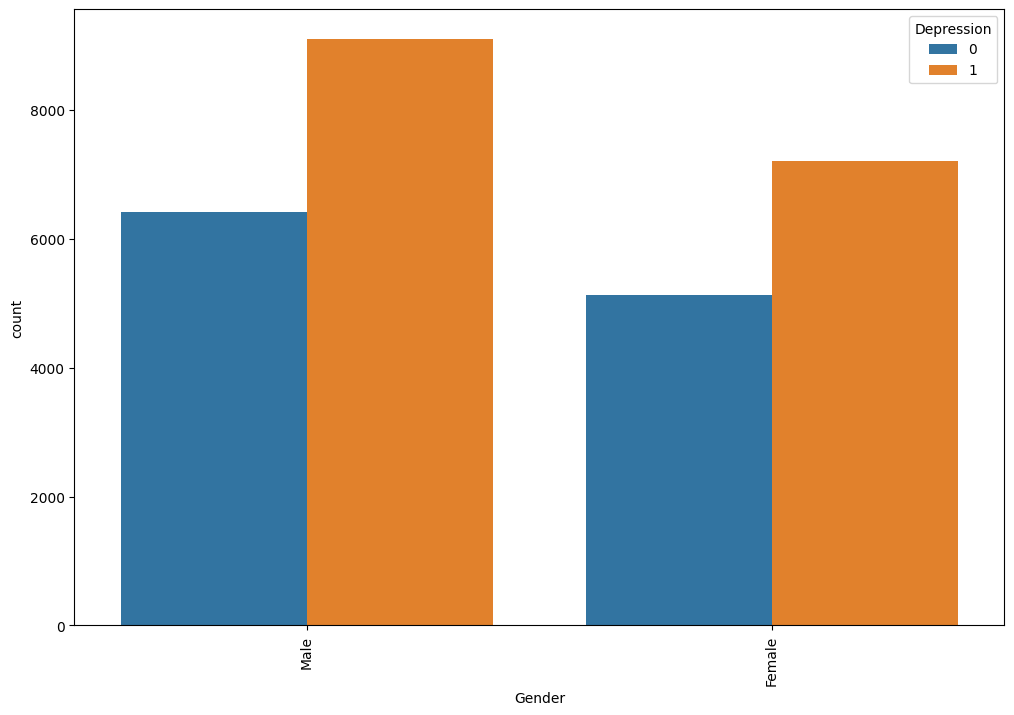

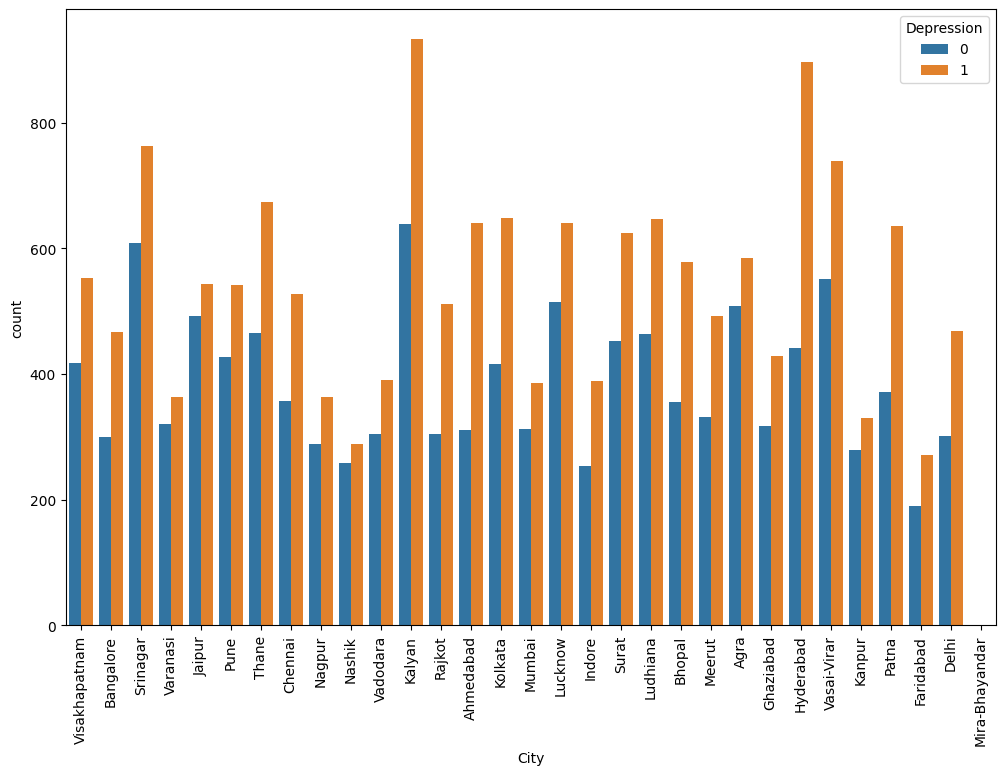

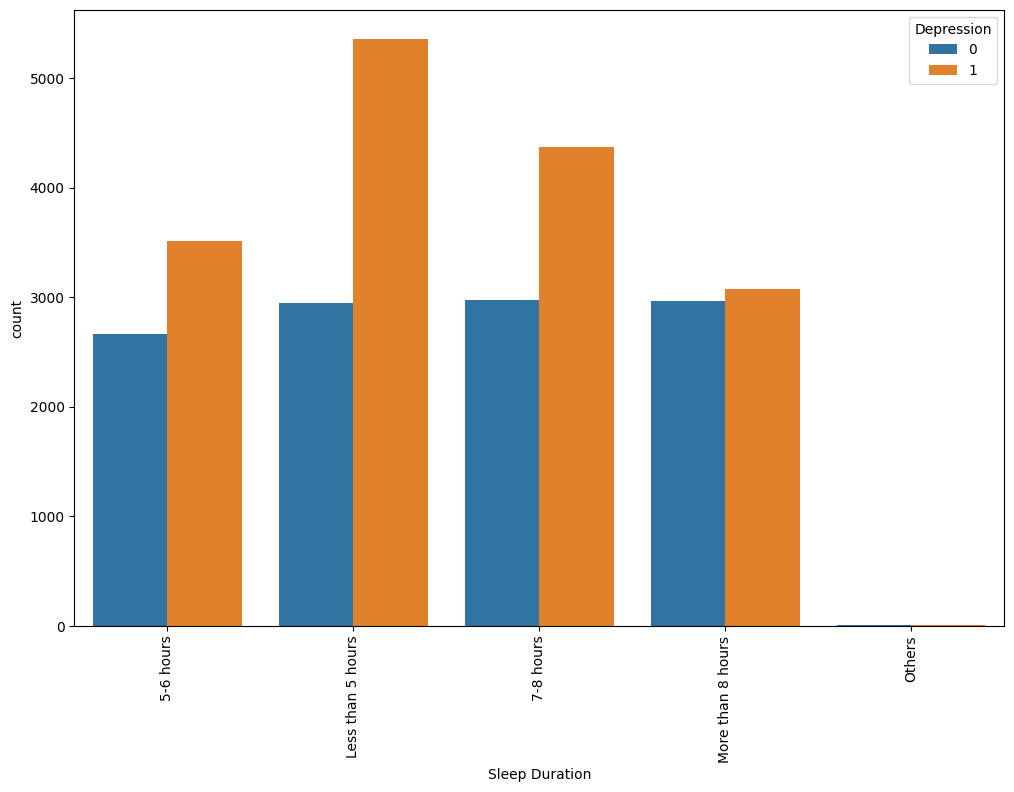

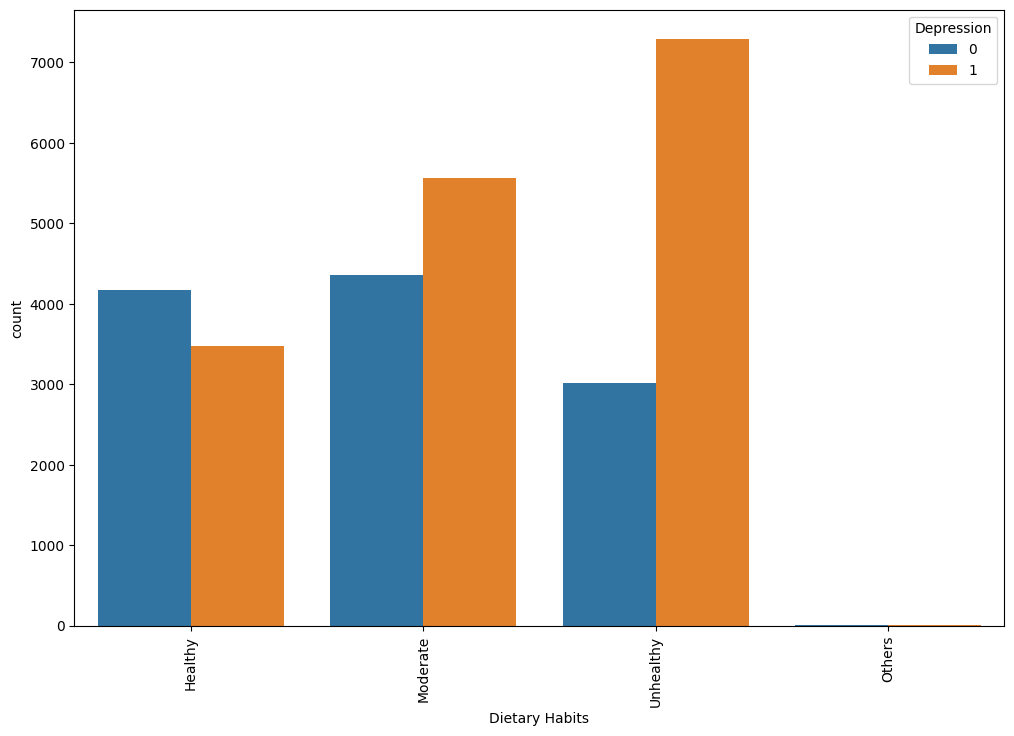

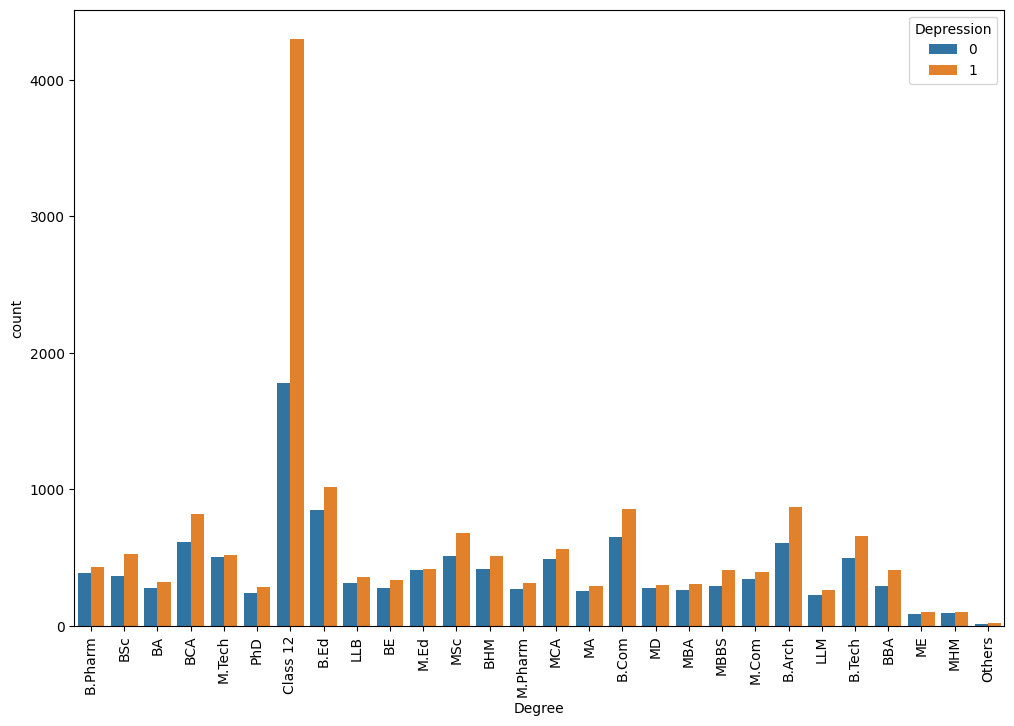

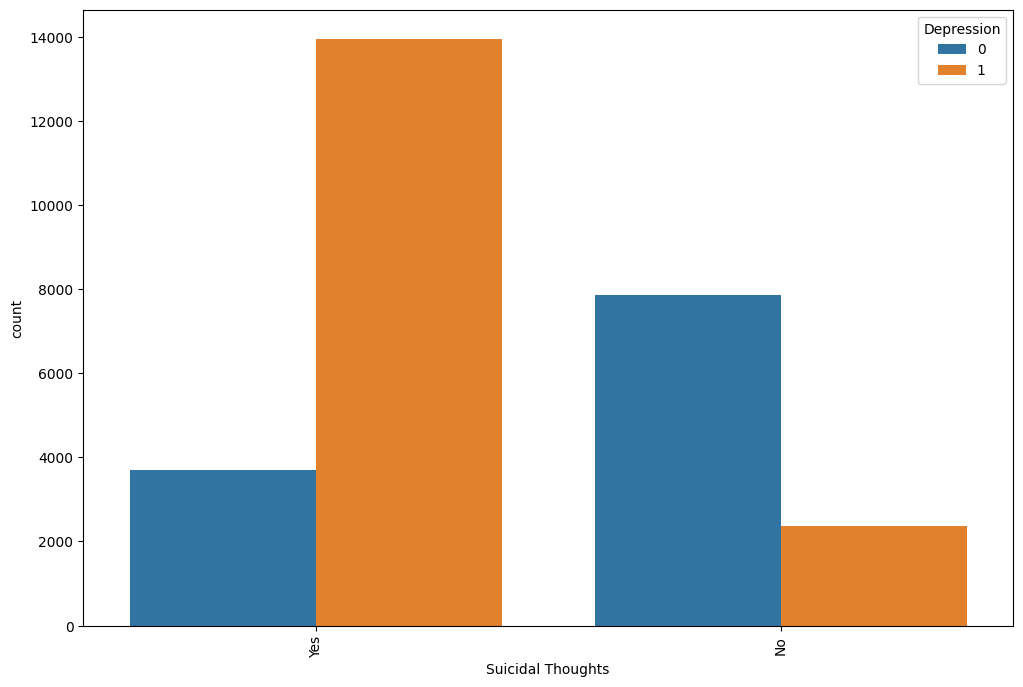

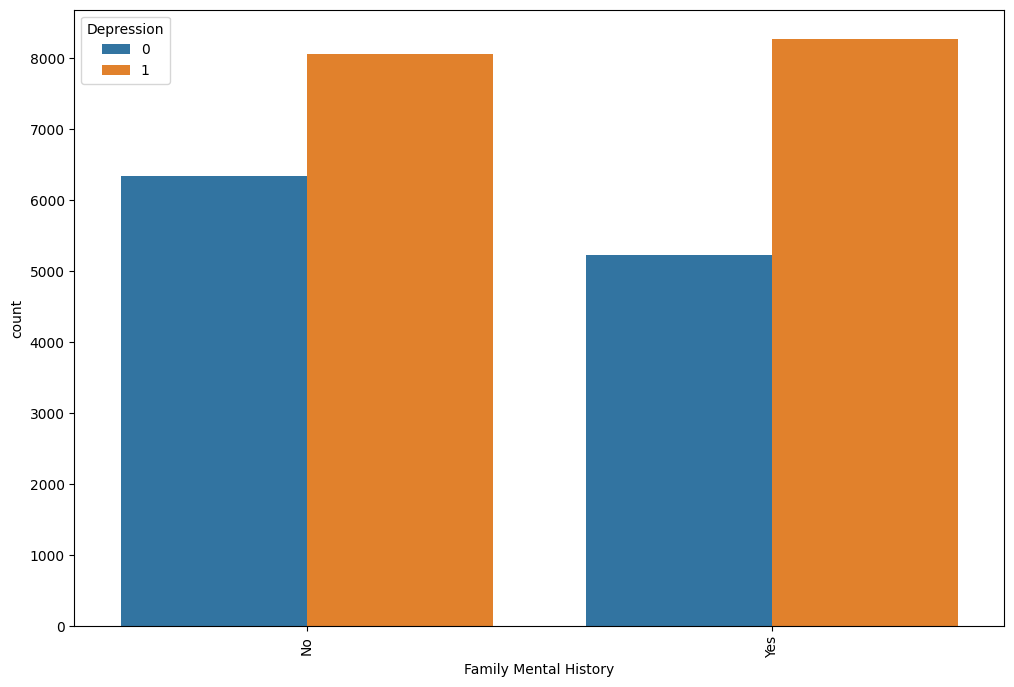

In [22]:
# bivariate analysis for the non-numerical column
target='Depression'
for col in df.select_dtypes('object'):
    plt.figure(figsize=(12,8))
    sns.countplot(x=col,hue=target,data=df)
    plt.xticks(rotation=90)


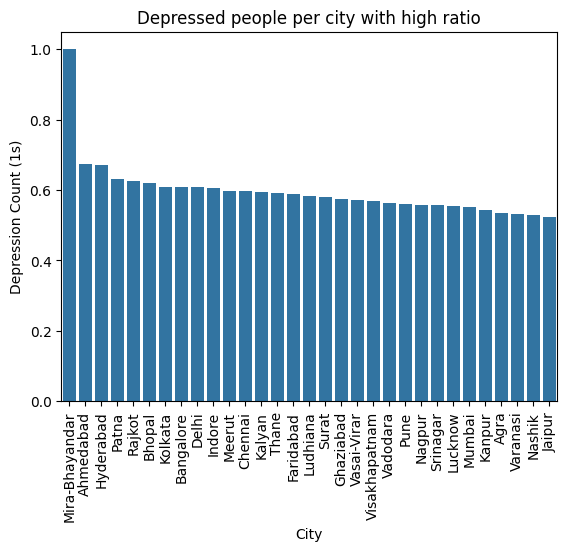

In [23]:
# groupby analysis
city_depression_count = df.groupby('City')['Depression'].mean().sort_values(ascending=False)
sns.barplot(x=city_depression_count.index, y=city_depression_count.values)
plt.xticks(rotation=90)
plt.title("Depressed people per city with high ratio")
plt.xlabel("City")
plt.ylabel("Depression Count (1s)")
plt.show()


(array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 [Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5'),
  Text(5.0, 0, '5.0'),
  Text(5.5, 0, '5.5')])

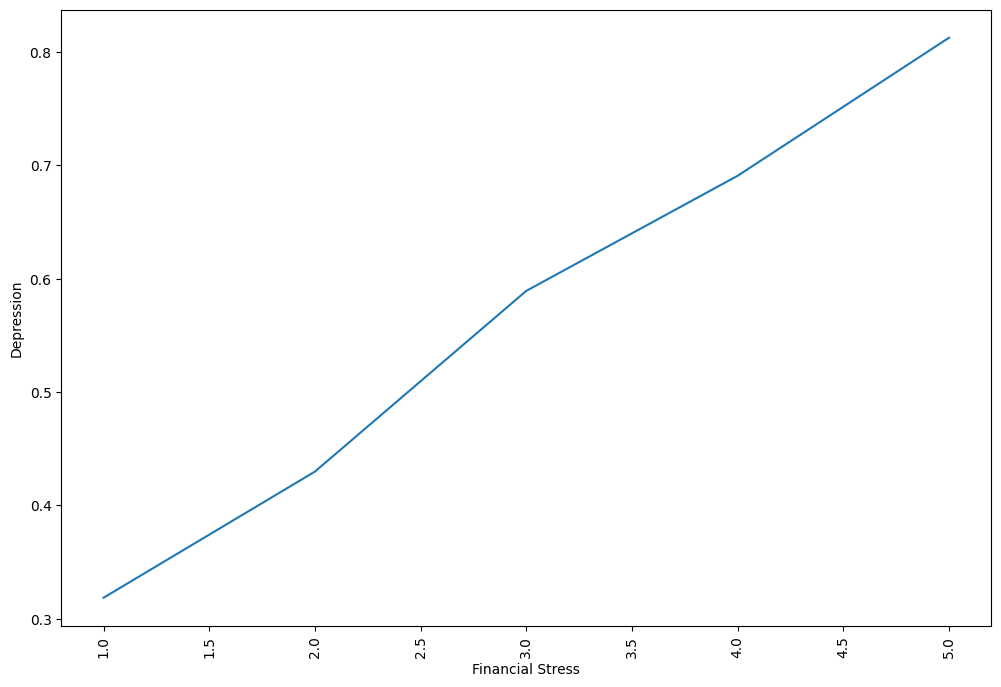

In [24]:
trend='Financial Stress'
target='Depression'
plt.figure(figsize=(12,8))
sns.lineplot(x=trend,y=target,data=df,errorbar=None)
plt.xticks(rotation=90)

In [25]:
x=df.drop('Depression',axis=1)
y=df[['Depression']]
x.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Suicidal Thoughts,Study Hours,Financial Stress,Family Mental History
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No
1,Female,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes
2,Male,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes
3,Female,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes
4,Female,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No


In [26]:
y.head()

,Depression
0,1
1,0
2,0
3,1
4,0


<Axes: xlabel='Depression', ylabel='count'>

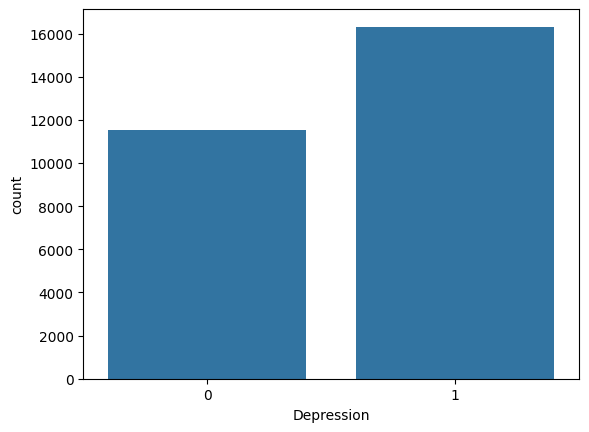

In [27]:
sns.countplot(x=y['Depression'])

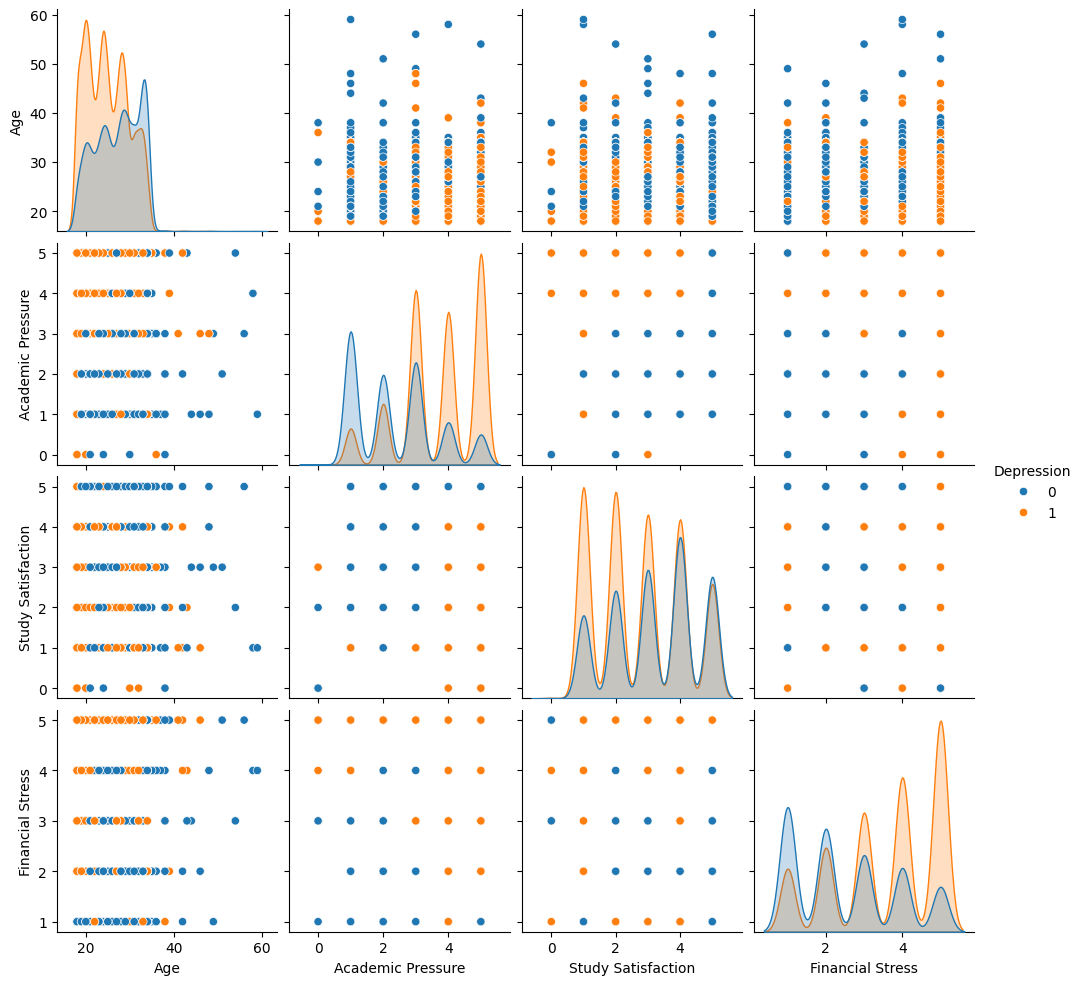

In [28]:
# pairwise relationship using pairplot
pr=df[['Age','Academic Pressure','Study Satisfaction','Financial Stress','Depression']]
sns.pairplot(pr,hue='Depression')

## **TRAIN TEST SPLIT**

Train-test split means dividing your dataset into two parts:

1. Training Set

- The model learns from this data

- Like studying from a textbook

2. Test Set

- The model is tested on this data

- Like writing an exam

- The model has never seen this data before

**TRAIN TEST SPLIT** is used to check whether the model learned real patterns or just memorized the training data

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.3,random_state=42,stratify=y)

In [30]:
norminal_high_card=['City','Degree']
norminal_low_card=['Gender','Dietary Habits','Suicidal Thoughts','Family Mental History']
ordinal=['Sleep Duration']
f_scal=['Age','Academic Pressure', 'CGPA', 'Study Satisfaction', 'Study Hours','Financial Stress']

In [31]:
print(df['Sleep Duration'].unique())

['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others']


In [32]:
preprocessor=ColumnTransformer(
    transformers=[
        ('target',TargetEncoder(),norminal_high_card),
        ('onehot',OneHotEncoder(drop='first'),norminal_low_card),
        ('ordinal',OrdinalEncoder(categories=[['Less than 5 hours','5-6 hours', '7-8 hours' ,'More than 8 hours','Others']]),ordinal),
        ('robust',RobustScaler(),f_scal)
    ]
)

## **ML PIPELINE**

A pipeline in machine learning is a step-by-step process that automatically applies all necessary tasks—like preprocessing, scaling, encoding, and training the model—in the correct order.

In [33]:
feat_sel=SelectKBest(score_func=f_classif,k=10)

In [34]:

pipeline=Pipeline(
    steps=[
        ('preprocess',preprocessor),
        ('bestFeature',feat_sel),
        ('sampler',SMOTE(random_state=42)),
        ('model',SVC(kernel='rbf',C=1.0,gamma='scale'))
        # ('model',XGBClassifier())
    ]
)

In [35]:
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto'],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [36]:
# training steps
# machine learning model learns patterns from the training data.
grid.fit(x_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__gamma': ['scale', 'auto']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('target', ...), ('onehot', ...), ...]"


In [37]:
# predicting 
ypred=grid.predict(x_train)

In [38]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_train
res['predicted']=ypred
res.reset_index(drop=True)
res

,actual,predicted
2363,1,1
5754,0,1
26767,0,0
20327,1,1
15685,0,0
...,...,...
11510,1,1
7140,1,1
16116,1,1
22366,1,0


## **Accuracy**

How many predictions are correct out of all predictions.

## **Precision**

Of all the items predicted as Positive, how many were actually Positive.

“When the model says Yes, how often is it correct?”

## **Recall**

Of all the actual Positive items, how many did the model correctly detect.

 “How many real positives did the model catch?”

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      3558
           1       0.86      0.87      0.86      4805

    accuracy                           0.84      8363
   macro avg       0.84      0.84      0.84      8363
weighted avg       0.84      0.84      0.84      8363

0.8431184981465981


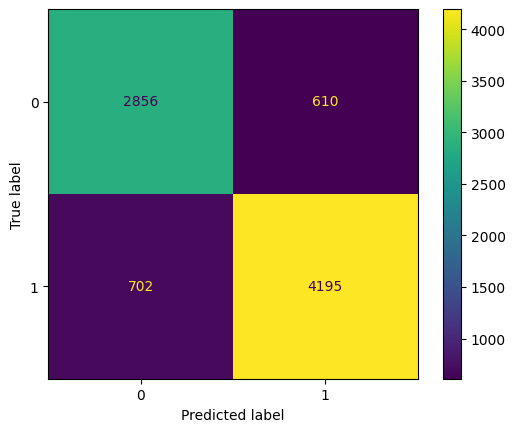

In [39]:
print(classification_report(ypred,y_train))
print(accuracy_score(ypred,y_train))
ConfusionMatrixDisplay.from_estimator(grid, x_train, y_train)
plt.show()

In [40]:
ypred=grid.predict(x_test)

In [41]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=ypred
res.reset_index(drop=True)
res

,actual,predicted
12069,1,1
24587,0,0
14609,0,0
22671,0,0
18482,0,0
...,...,...
7457,1,1
23045,1,1
8644,1,1
8460,1,1


              precision    recall  f1-score   support

           0       0.82      0.80      0.81      8310
           1       0.85      0.87      0.86     11204

    accuracy                           0.84     19514
   macro avg       0.84      0.84      0.84     19514
weighted avg       0.84      0.84      0.84     19514

0.8414984113969458


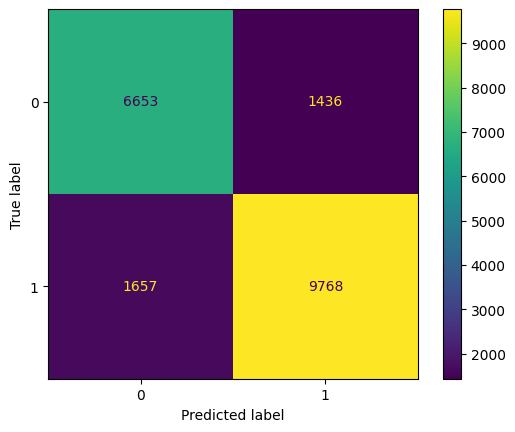

In [42]:
print(classification_report(ypred,y_test))
print(accuracy_score(ypred,y_test))
ConfusionMatrixDisplay.from_predictions(y_test,ypred)
plt.show()

## **CONCLUSION**

The SVM model shows excellent generalization with almost identical train and test accuracies
(Train: 0.8431 • Test: 0.8414), indicating no overfitting or underfitting.

Precision, recall, and F1-scores are balanced across both classes, with Class 1 performing slightly better, which is expected given the mild class imbalance (0: 8310, 1: 11204). Macro and weighted averages are equal (0.84), showing that the model performs consistently for all classes.

Overall, the model is stable, well-tuned, and a strong candidate for final selection, demonstrating reliable performance and good generalization on unseen data.

In comparison:

- Random Forest shows clear overfitting

  - Train Accuracy: 0.92

  - Test Accuracy: 0.83
  - The large gap suggests the model is learning noise and not generalizing as well as SVM.

- XGBoost is even more overfitted

  - Train Accuracy: 0.97

  - Test Accuracy: 0.84
  - Very high training accuracy with a much lower test score indicates strong overfitting despite good test performance.

**Final Verdict**

- SVM is the most stable and generalizing model
- Random Forest and XGBoost show high overfitting, making them less reliable
- SVM achieves the best balance between bias and variance